# Personen im Asylwesen nach Nationalitäten und Status, seit 2018

Diese Daten beschreiben Personen im Asylwesen nach Nationalitäten und Status


Datum: 20.11.2025

**Dataset auf INTEG Datenkatalog**:  https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_monat_asylwesen_status_nationalitaet_od5236

**Dataset auf PROD Datenkatalog**:  https://data.stadt-zuerich.ch/dataset/bev_monat_asylwesen_status_nationalitaet_od5236

### Importiere die notwendigen Packages

In [102]:
import pandas as pd
import numpy as np
import altair as alt
import datetime
import geopandas as gpd
import folium 
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import requests
import io


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [103]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [104]:
#help(mypy_dv)
help(mypy_dl)

Help on module my_py_dataloading_functions:

NAME
    my_py_dataloading_functions

FUNCTIONS
    load_data(status, data_source, package_name, dataset_name, **kwargs)
        Diese Funktion importiert die gewünschten Daten je nach Status (Int/Prod) und Speicherort (Dropzone/Web) in Pandas ein.
        
        Parameter:
        - status (str): sind die Daten auf Integ ('int') oder auf Prod ('prod') zu beziehen? 
        - data_source (str): sind die Daten im Internet ('web'), LOSD ('ld') oder auf den Dropzones/Fileverzeichnis ('dropzone') zu beziehen?
        - package_name (str): Name des Packages. Dies entspricht dem Slug in der URL und auch dem Verzeichnisnamen auf der Dropzone. Z.B. 'bfs_bev_bildungsstand_seit1970_OD1002'
        - dataset_name (str): Name des Datensatzes (in CKAN der Ressource). z.B. "bev324od3242.csv"
        
        Optionale Parameter:
        - ckan_integ_url (str):  Pfad zur INT-Umgebung von CKAN. Default: 'https://data.integ.stadt-zuerich.ch/dataset/'
     

In [105]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [106]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [107]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Zeitvariabeln


In [108]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [109]:
package_name = "bev_monat_asylwesen_status_nationalitaet_geschlecht_od5236"

In [110]:
data2betested = mypy_dl.load_data(
    status = 'prod'
    , data_source = 'dropzone'
    , package_name = package_name
    , dataset_name = "BEV523OD5236"      
    , datums_attr = ['StichtagDat']
    )

fp lautet:\\szh\ssz\applikationen\OGD_Dropzone\DWH\bev_monat_asylwesen_status_nationalitaet_geschlecht_od5236\BEV523OD5236.csv
data_source: dropzone


In [111]:
data2betested.head(4).T

,0,1,2,3
Jahr,2018,2018,2018,2018
MonatSort,5,5,5,5
MonatLang,Mai,Mai,Mai,Mai
StichtagDat,2018-05-31 00:00:00,2018-05-31 00:00:00,2018-05-31 00:00:00,2018-05-31 00:00:00
AufenthaltsstatusSort,1,1,1,1
AufenthaltsstatusLang,Ausweis N,Ausweis N,Ausweis N,Ausweis N
SexSort,1,1,1,1
SexCd,1,1,1,1
SexLang,männlich,männlich,männlich,männlich
NationHistSort,8201,8239,8256,8264


Berechne weitere Attribute falls notwendig

In [112]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        Jahr_str = lambda x: x.Jahr.astype(str),

    )
    .sort_values('Jahr', ascending=False)
    )
data2betested.dtypes

Jahr                              int64
MonatSort                         int64
MonatLang                        object
StichtagDat              datetime64[ns]
AufenthaltsstatusSort             int64
AufenthaltsstatusLang            object
SexSort                           int64
SexCd                             int64
SexLang                          object
NationHistSort                    int64
NationHistCd                      int64
NationHistLang                   object
RegionSort                        int64
RegionCd                          int64
RegionLang                       object
KontinentSort                     int64
KontinentCd                       int64
KontinentLang                    object
Anzahl                            int64
Jahr_str                         object
dtype: object

In [113]:
data2betested.head(2)

,Jahr,MonatSort,MonatLang,StichtagDat,AufenthaltsstatusSort,AufenthaltsstatusLang,SexSort,...,RegionCd,RegionLang,KontinentSort,KontinentCd,KontinentLang,Anzahl,Jahr_str
16441,2025,10,Oktober,2025-10-31,3,Ausweis S,2,...,43,Zentralasien,4,4,Asien,1,2025
14681,2025,9,September,2025-09-30,2,Ausweis F,2,...,24,Westafrika,2,2,Afrika,3,2025


Minimales und maximales Jahr im Datensatz

In [114]:
data_max_date = str(max(data2betested.StichtagDat).year)
data_min_date = str(min(data2betested.StichtagDat).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 2018 und ein Maximumjahr von 2025


### Einfache Datentests

In [115]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 16442 entries, 16441 to 0
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Jahr                   16442 non-null  int64         
 1   MonatSort              16442 non-null  int64         
 2   MonatLang              16442 non-null  object        
 3   StichtagDat            16442 non-null  datetime64[ns]
 4   AufenthaltsstatusSort  16442 non-null  int64         
 5   AufenthaltsstatusLang  16442 non-null  object        
 6   SexSort                16442 non-null  int64         
 7   SexCd                  16442 non-null  int64         
 8   SexLang                16442 non-null  object        
 9   NationHistSort         16442 non-null  int64         
 10  NationHistCd           16442 non-null  int64         
 11  NationHistLang         16442 non-null  object        
 12  RegionSort             16442 non-null  int64         
 13  Region

In [116]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 16,442 rows (observations) and 20 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [117]:
data2betested.describe()

,Jahr,MonatSort,StichtagDat,AufenthaltsstatusSort,SexSort,SexCd,NationHistSort,NationHistCd,RegionSort,RegionCd,KontinentSort,KontinentCd,Anzahl
count,16442,16442,16442,16442,16442,16442,16442,16442,16442,16442,16442,16442,16442
mean,2022,7,2022-06-18 05:13:16.545432320,2,1,1,8418,8418,32,32,3,3,24
min,2018,1,2018-05-31 00:00:00,1,1,1,8201,8201,12,12,1,1,1
25%,2020,4,2020-06-30 00:00:00,1,1,1,8311,8311,22,22,2,2,1
50%,2022,7,2022-09-30 00:00:00,2,1,1,8359,8359,24,24,2,2,2
75%,2024,9,2024-05-31 00:00:00,2,2,2,8513,8513,44,44,4,4,8
max,2025,12,2025-10-31 00:00:00,3,2,2,8999,8999,88,88,8,8,1873
std,2,3,NaN,1,0,0,160,160,16,16,2,2,113


Welches sind die Quartiere ohne Werte bei BEW?

In [118]:
data2betested[np.isnan(data2betested.Anzahl)]

,Jahr,MonatSort,MonatLang,StichtagDat,AufenthaltsstatusSort,AufenthaltsstatusLang,SexSort,...,RegionCd,RegionLang,KontinentSort,KontinentCd,KontinentLang,Anzahl,Jahr_str


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [119]:
data2betested = data2betested.set_index("StichtagDat")
data2betested = data2betested.sort_index()

In [120]:
data2betested.index.year.unique()

Index([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype='int32', name='StichtagDat')

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [121]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number'))
except:
    print("No categorical data in dataset.")

,MonatLang,AufenthaltsstatusLang,SexLang,NationHistLang,RegionLang,KontinentLang,Jahr_str
count,16442,16442,16442,16442,16442,16442,16442
unique,12,3,2,108,25,5,8
top,Juni,Ausweis F,männlich,Russland,Westafrika,Afrika,2024
freq,1477,8376,9065,445,2030,6328,2739


Beschreibe numerische Attribute

In [122]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,Jahr,MonatSort,AufenthaltsstatusSort,SexSort,SexCd,NationHistSort,NationHistCd,RegionSort,RegionCd,KontinentSort,KontinentCd,Anzahl
count,"16,442","16,442","16,442","16,442","16,442","16,442","16,442","16,442","16,442","16,442","16,442","16,442"
mean,"2,022",7,2,1,1,"8,418","8,418",32,32,3,3,24
std,2,3,1,0,0,160,160,16,16,2,2,113
min,"2,018",1,1,1,1,"8,201","8,201",12,12,1,1,1
25%,"2,020",4,1,1,1,"8,311","8,311",22,22,2,2,1
50%,"2,022",7,2,1,1,"8,359","8,359",24,24,2,2,2
75%,"2,024",9,2,2,2,"8,513","8,513",44,44,4,4,8
max,"2,025",12,3,2,2,"8,999","8,999",88,88,8,8,"1,873"


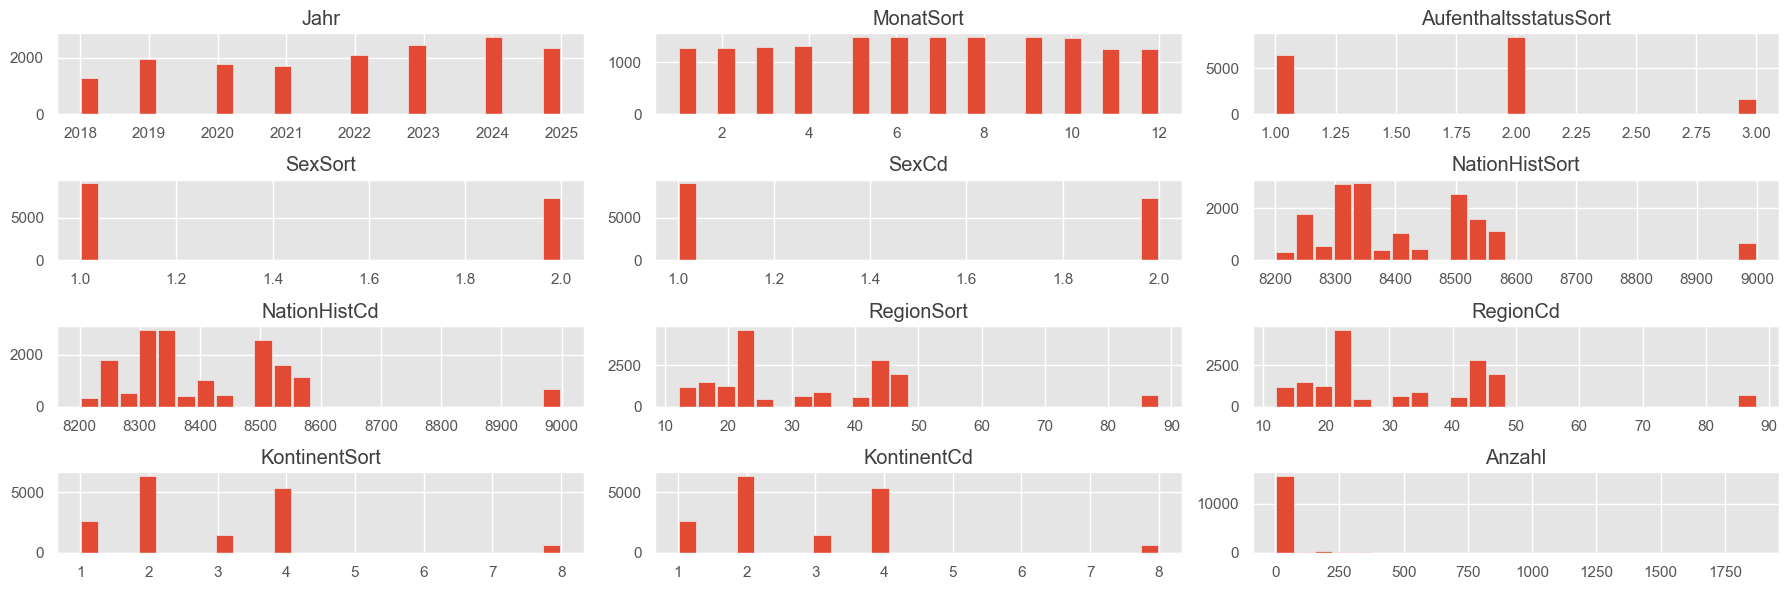

In [123]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [124]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,Jahr,MonatSort,MonatLang,AufenthaltsstatusSort,AufenthaltsstatusLang,SexSort,SexCd,...,RegionCd,RegionLang,KontinentSort,KontinentCd,KontinentLang,Anzahl,Jahr_str
StichtagDat,,,,,,,,,,,,,,,


### Nullwerte und Missings?

In [125]:
data2betested.isnull().sum()

Jahr                     0
MonatSort                0
MonatLang                0
AufenthaltsstatusSort    0
AufenthaltsstatusLang    0
SexSort                  0
SexCd                    0
SexLang                  0
NationHistSort           0
NationHistCd             0
NationHistLang           0
RegionSort               0
RegionCd                 0
RegionLang               0
KontinentSort            0
KontinentCd              0
KontinentLang            0
Anzahl                   0
Jahr_str                 0
dtype: int64

In [126]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [127]:
agg_jahr_mt = data2betested.loc["1992":year_today]\
    .groupby(['Jahr','MonatSort','MonatLang', 'StichtagDat']) \
    .agg(sum_AnzPers=('Anzahl', 'sum')) \
    .sort_values('StichtagDat', ascending=False) 
agg_jahr_mt.reset_index().head(3)

,Jahr,MonatSort,MonatLang,StichtagDat,sum_AnzPers
0,2025,10,Oktober,2025-10-31,6546
1,2025,9,September,2025-09-30,6529
2,2025,8,August,2025-08-31,6443


In [128]:
agg_Status = data2betested.loc["1930":year_today]\
    .groupby(['AufenthaltsstatusSort', 'AufenthaltsstatusLang']) \
    .agg(sum_AnzPers=('Anzahl', 'sum')) \
    .sort_values('AufenthaltsstatusSort', ascending=False) 
agg_Status.reset_index().head(40)

,AufenthaltsstatusSort,AufenthaltsstatusLang,sum_AnzPers
0,3,Ausweis S,114745
1,2,Ausweis F,235651
2,1,Ausweis N,41603


In [129]:
agg_NationHist = data2betested.loc["1930":year_today]\
    .groupby(['NationHistSort','NationHistCd', 'NationHistLang', ]) \
    .agg(sum_Anzahl=('Anzahl', 'sum')) \
    .sort_values('NationHistSort', ascending=False) 
agg_NationHist.reset_index().head(5)

,NationHistSort,NationHistCd,NationHistLang,sum_Anzahl
0,8999,8999,Staat unbekannt,2532
1,8998,8998,Staatenlos,1439
2,8567,8567,Usbekistan,89
3,8566,8566,Turkmenistan,82
4,8565,8565,Tadschikistan,9


In [130]:
agg_Regions = data2betested.loc["1930":year_today]\
    .groupby(['RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort',
              'KontinentCd', 'KontinentLang','NationHistSort','NationHistCd', 'NationHistLang' ]) \
    .agg(sum_Anzahl=('Anzahl', 'sum')) \
    .sort_values('NationHistSort', ascending=True) 
agg_Regions.reset_index().head(5)

,RegionSort,RegionCd,RegionLang,KontinentSort,KontinentCd,KontinentLang,NationHistSort,NationHistCd,NationHistLang,sum_Anzahl
0,17,17,Südosteuropa,1,1,Europa,8201,8201,Albanien,265
1,17,17,Südosteuropa,1,1,Europa,8205,8205,Bulgarien,1
2,13,13,Zentraleuropa,1,1,Europa,8207,8207,Deutschland,128
3,14,14,Westeuropa,1,1,Europa,8212,8212,Frankreich,1
4,14,14,Westeuropa,1,1,Europa,8215,8215,Grossbritannien,56


### Pivotiere

In [131]:
data2betested.columns

Index(['Jahr', 'MonatSort', 'MonatLang', 'AufenthaltsstatusSort', 'AufenthaltsstatusLang',
       'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd', 'NationHistLang',
       'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd', 'KontinentLang',
       'Anzahl', 'Jahr_str'],
      dtype='object')

In [132]:
pivoted_df = data2betested.pivot_table(
    index='Jahr',
    columns=['NationHistSort', 'NationHistCd', 'NationHistLang'],
    values='Anzahl',
    aggfunc='mean'
)

pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
pivoted_df.head(8).T

,,Jahr,2025,2024,2023,2022,2021,2020,2019,2018
NationHistSort,NationHistCd,NationHistLang,,,,,,,,
8265,8265,Ukraine,698,565,622,523,NaN,1,1,2
8501,8501,Afghanistan,134,143,149,79,108,109,103,103
8362,8362,Eritrea,130,138,158,163,152,153,158,159
8541,8541,Syrien,108,111,110,109,133,128,138,134
8348,8348,Somalia,68,70,73,101,112,110,112,116
...,...,...,...,...,...,...,...,...,...,...
8415,8415,Guatemala,NaN,NaN,1,1,NaN,NaN,NaN,NaN
8421,8421,Jamaika,NaN,1,1,1,1,1,2,NaN
8427,8427,Mexiko,NaN,NaN,1,1,NaN,1,NaN,NaN


In [133]:
pivoted_df_diff = pivoted_df.sort_index(ascending=True).diff()
pivoted_df_diff.tail(5)

NationHistSort,8265,8501,8362,8541,8348,8239,8506,...,8325,8341,8415,8421,8427,8429,8534
NationHistCd,8265,8501,8362,8541,8348,8239,8506,...,8325,8341,8415,8421,8427,8429,8534
NationHistLang,Ukraine,Afghanistan,Eritrea,Syrien,Somalia,Türkei,Sri Lanka,...,Liberia,Ruanda,Guatemala,Jamaika,Mexiko,Nicaragua,Philippinen
Jahr,,,,,,,,,,,,,,,
2021,NaN,-1,-1,5,1,1,-7,...,NaN,0,NaN,0,NaN,NaN,0
2022,NaN,-29,10,-25,-11,1,-4,...,NaN,NaN,NaN,0,NaN,NaN,0
2023,99,70,-4,2,-27,24,-0,...,NaN,NaN,0,0,0,NaN,NaN
2024,-56,-6,-21,0,-4,30,3,...,NaN,NaN,NaN,0,NaN,NaN,NaN
2025,133,-8,-8,-3,-1,-5,-1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Visualisierungen nach Zeitausschnitten

#### Top Nationen des aktuellen Jahrs

In [134]:
#    .query('FzMarkeLang!="Rover"')\
agg_nation_years = data2betested\
    .groupby(['StichtagDat','Jahr','NationHistSort', 'NationHistCd', 'NationHistLang']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values(['StichtagDat','sum_Anz'], ascending=[False, False]) 
agg_nation_years.reset_index().head(10)

,StichtagDat,Jahr,NationHistSort,NationHistCd,NationHistLang,sum_Anz
0,2025-10-31,2025,8265,8265,Ukraine,3107
1,2025-10-31,2025,8501,8501,Afghanistan,806
2,2025-10-31,2025,8362,8362,Eritrea,527
3,2025-10-31,2025,8541,8541,Syrien,417
4,2025-10-31,2025,8348,8348,Somalia,346
5,2025-10-31,2025,8239,8239,Türkei,277
6,2025-10-31,2025,8506,8506,Sri Lanka,90
7,2025-10-31,2025,8508,8508,China,86
8,2025-10-31,2025,8302,8302,Äthiopien,84
9,2025-10-31,2025,8513,8513,Iran,79


Mach eine Liste mit den Top15 Fahrzeugen im aktuellen Jahr

In [135]:
data_max_date = max(data2betested.index)

In [136]:
df_top_25 = agg_nation_years.loc[data_max_date].sort_values('sum_Anz', ascending=False).head(25).reset_index()
df_top_5 = agg_nation_years.loc[data_max_date].sort_values('sum_Anz', ascending=False).head(5).reset_index()

In [137]:
list_top_25_latest_year = df_top_25['NationHistLang'].tolist()
list_top_5_latest_year = df_top_5['NationHistLang'].tolist()
#list_top_25_latest_year


In [138]:
list_top_25_latest_year

['Ukraine',
 'Afghanistan',
 'Eritrea',
 'Syrien',
 'Somalia',
 'Türkei',
 'Sri Lanka',
 'China',
 'Äthiopien',
 'Iran',
 'Irak',
 'Kongo (Kinshasa)',
 'Russland',
 'Angola',
 'Georgien',
 'Guinea',
 'Sudan',
 'Kamerun',
 'Pakistan',
 'Kolumbien',
 'Venezuela',
 'Staat unbekannt',
 "Côte d'Ivoire",
 'Bosnien und Herzegowina',
 'Kosovo']

Wähle aus dem nach Jahr aggregierten Dataframe nur jene aus der Top25-Liste aus

In [139]:
agg_nation_years.reset_index()
#agg_nation_years.reset_index().query('NationHistLang in @list_top_25_latest_year')

,StichtagDat,Jahr,NationHistSort,NationHistCd,NationHistLang,sum_Anz
0,2025-10-31,2025,8265,8265,Ukraine,3107
1,2025-10-31,2025,8501,8501,Afghanistan,806
2,2025-10-31,2025,8362,8362,Eritrea,527
3,2025-10-31,2025,8541,8541,Syrien,417
4,2025-10-31,2025,8348,8348,Somalia,346
...,...,...,...,...,...,...
6597,2018-05-31,2018,8432,8432,Peru,1
6598,2018-05-31,2018,8438,8438,Venezuela,1
6599,2018-05-31,2018,8514,8514,Israel,1
6600,2018-05-31,2018,8525,8525,Malaysia,1


In [140]:
df_sel_top25_since2002 = agg_nation_years.reset_index().query('NationHistLang in @list_top_25_latest_year')
df_sel_top5_since2002 = agg_nation_years.reset_index().query('NationHistLang in @list_top_5_latest_year')
#df_sel_top25_since2002

In [141]:
df_sel_top25_since2002.head(2)

,StichtagDat,Jahr,NationHistSort,NationHistCd,NationHistLang,sum_Anz
0,2025-10-31,2025,8265,8265,Ukraine,3107
1,2025-10-31,2025,8501,8501,Afghanistan,806


In [142]:
grafik0 = mypy_dv.plot_altair_multiline_highlight(
    data = df_sel_top25_since2002.query("NationHistSort ==8265").reset_index().sort_values('NationHistLang', ascending=True)
    ,x = 'StichtagDat:T'
    ,y = 'sum_Anz:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "NationHistLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der Personen im Asylwesen aus der Ukraine "+str(data_min_date)
)
grafik0

alt.LayerChart(...)

In [143]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = df_sel_top25_since2002.query("NationHistSort !=8265").reset_index().sort_values('NationHistLang', ascending=True)
    ,x = 'StichtagDat:T'
    ,y = 'sum_Anz:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "NationHistLang:N"
    ,category_beschriftung= 'Legende:'
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der häufigsten Nationen ohne die Ukraine seit "+str(data_min_date)
)
grafik1

alt.LayerChart(...)

#### Barcharts mit Seaborn

#### Entwicklung Personen im Asyl nach ...

In [144]:
df_sel_top25_since2002.columns

Index(['StichtagDat', 'Jahr', 'NationHistSort', 'NationHistCd', 'NationHistLang', 'sum_Anz'], dtype='object')

In [145]:
myAggBar = df_sel_top25_since2002

In [146]:
#help(sns.catplot)   
# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")


In [147]:
latest_month = myAggBar['StichtagDat'].max()
latest_month = latest_month.strftime('%Y-%m-%d')

print(latest_month)

2025-10-31


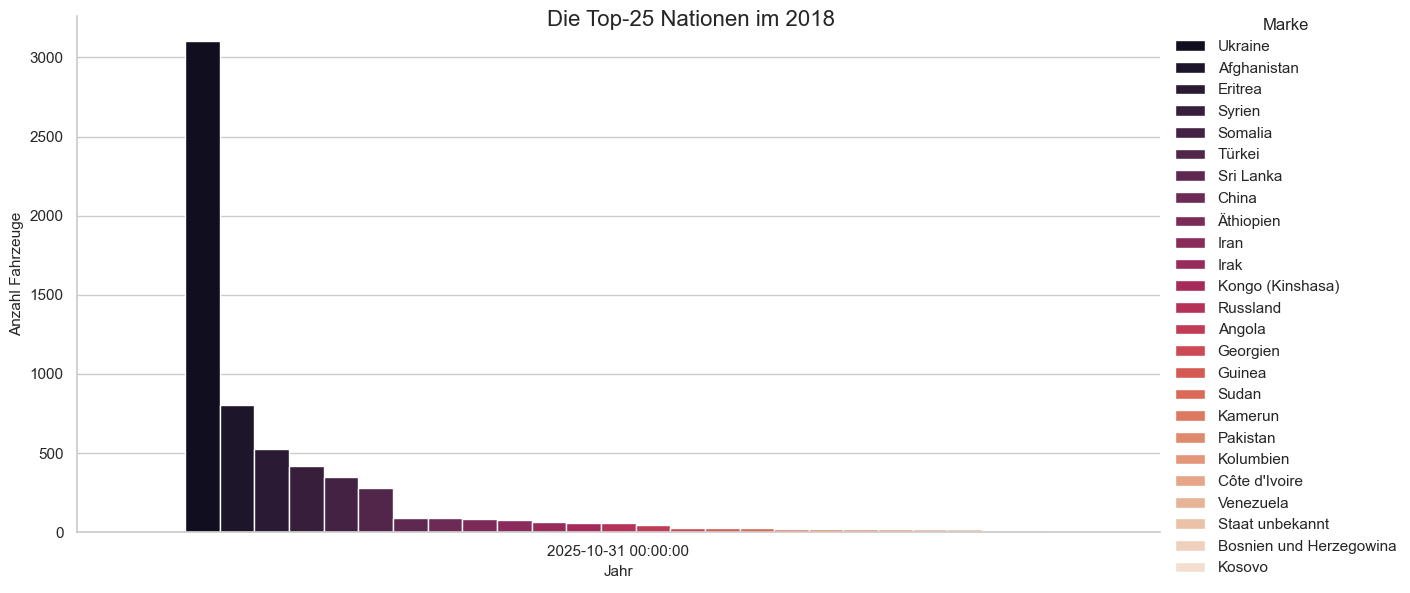

In [148]:
myHist = sns.catplot(x="StichtagDat"
            , y="sum_Anz"
            , hue="NationHistLang"
            , kind="bar" #boxen, violin, --> wenn die aggregation nicht genau den werten in der grafik entspricht
            , palette="rocket" # "cubehelix", "rocket", "pastel", color="green" 
            , height=6
            , aspect=2
            , order=None, legend_out=True
            ,data=myAggBar.query("StichtagDat == @latest_month").reset_index()
            )
myHist.set_xlabels('Jahr', fontsize=11) # not set_label
myHist.set_ylabels('Anzahl Fahrzeuge', fontsize=11)

# Titel hinzufügen
myHist.fig.suptitle('Die Top-25 Nationen im '+data_min_date, fontsize=16)
# Legende anpassen
myHist.legend.set_title('Marke')
# Layout anpassen
#plt.tight_layout()
# Plot anzeigen
plt.show()

In [149]:
myAggBar = df_sel_top5_since2002
myAggBar['StichtagDat_str'] = myAggBar['StichtagDat'].astype(str)
myAggBar.columns
myAggBar.head(2)

,StichtagDat,Jahr,NationHistSort,NationHistCd,NationHistLang,sum_Anz,StichtagDat_str
0,2025-10-31,2025,8265,8265,Ukraine,3107,2025-10-31
1,2025-10-31,2025,8501,8501,Afghanistan,806,2025-10-31


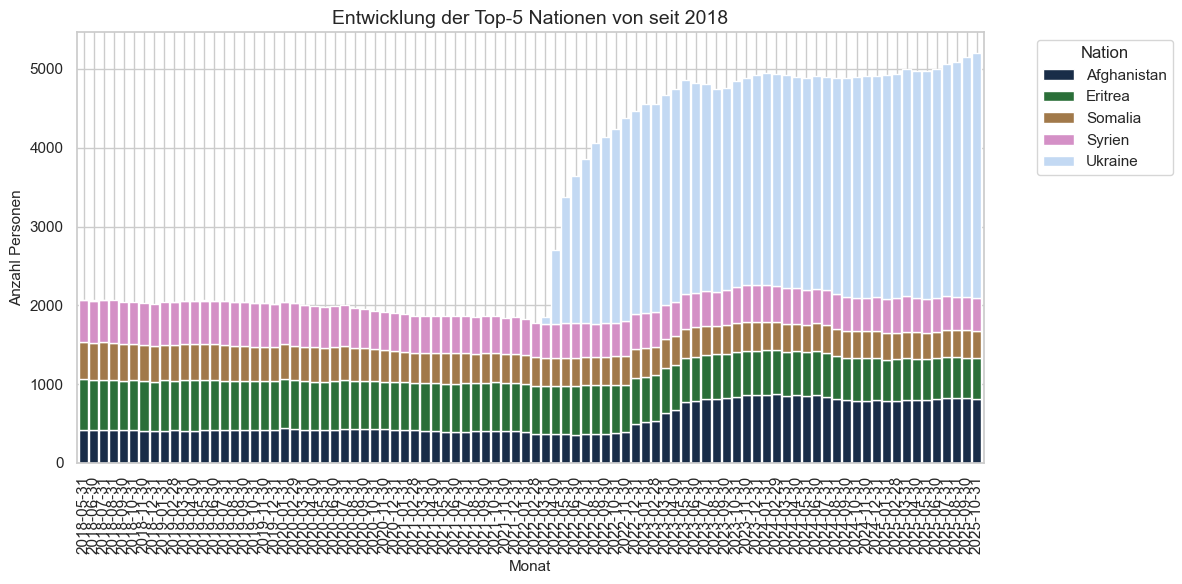

In [150]:
# Daten vorbereiten (angenommen, myAggBar ist Ihr DataFrame)
myAggBar = df_sel_top5_since2002

data = myAggBar.query("sum_Anz > 0").reset_index()
data_pivoted = data.pivot(index='StichtagDat_str', columns='NationHistLang', values='sum_Anz').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("cubehelix", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Entwicklung der Top-5 Nationen von seit '+data_min_date, fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Monat', fontsize=11)
ax.set_ylabel('Anzahl Personen', fontsize=11)

# Legende anpassen
plt.legend(title='Nation', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

#### Faced Grids

In [151]:
data2betested.reset_index().columns

Index(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'AufenthaltsstatusSort',
       'AufenthaltsstatusLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd',
       'NationHistLang', 'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd',
       'KontinentLang', 'Anzahl', 'Jahr_str'],
      dtype='object')

In [152]:
myFG = data2betested.loc["2020":data_max_date]\
    .query('NationHistLang in @list_top_5_latest_year')\
    .groupby(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd', 'NationHistLang']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('NationHistSort', ascending=True) 

myFG.reset_index().head(3)

,StichtagDat,Jahr,MonatSort,MonatLang,SexSort,SexCd,SexLang,NationHistSort,NationHistCd,NationHistLang,sum_Anz
0,2020-01-31,2020,1,Januar,1,1,männlich,8265,8265,Ukraine,1
1,2022-10-31,2022,10,Oktober,2,2,weiblich,8265,8265,Ukraine,1696
2,2025-04-30,2025,4,April,1,1,männlich,8265,8265,Ukraine,1087


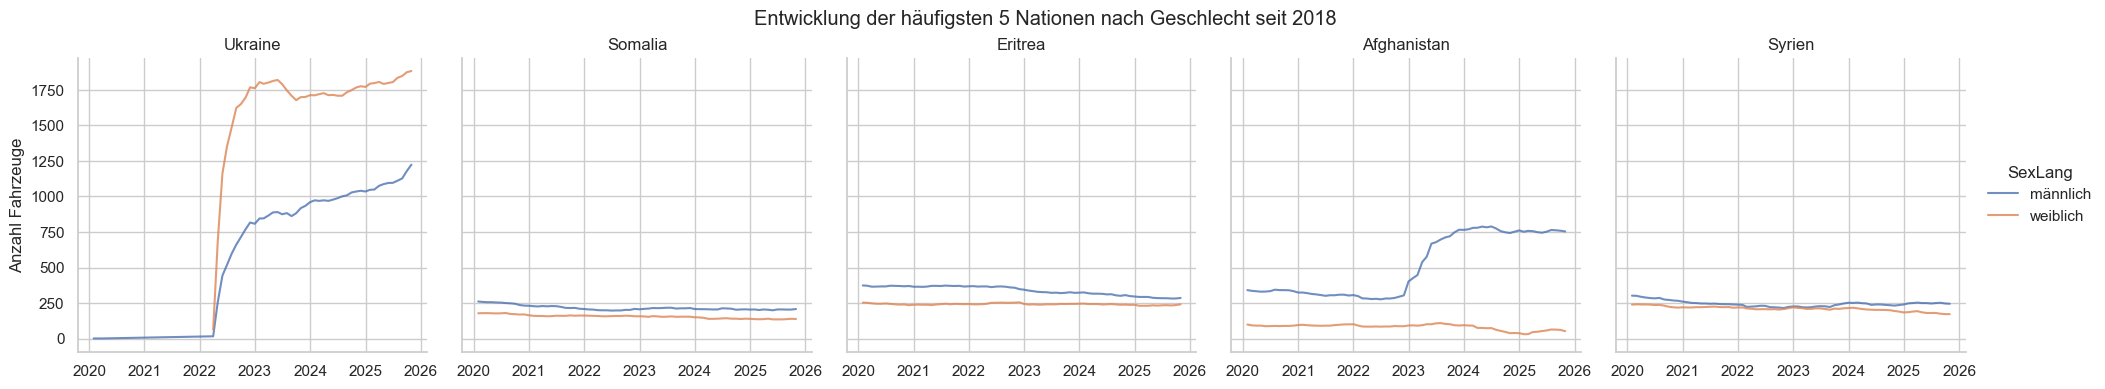

In [153]:
faced_grid = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('NationHistSort', ascending=True)
    ,col = "NationHistLang"
    ,hue = "SexLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_Anz"
    ,ylabel= "Anzahl Fahrzeuge"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der häufigsten 5 Nationen nach Geschlecht seit "+data_min_date
)
faced_grid

In [154]:
myFG1 = data2betested.loc["2020":data_max_date]\
    .query('NationHistLang in @list_top_25_latest_year')\
    .groupby(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd', 'NationHistLang']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('NationHistSort', ascending=True) 

myFG1.reset_index().head(3)

,StichtagDat,Jahr,MonatSort,MonatLang,SexSort,SexCd,SexLang,NationHistSort,NationHistCd,NationHistLang,sum_Anz
0,2020-01-31,2020,1,Januar,1,1,männlich,8239,8239,Türkei,34
1,2023-07-31,2023,7,Juli,1,1,männlich,8239,8239,Türkei,133
2,2023-06-30,2023,6,Juni,2,2,weiblich,8239,8239,Türkei,59


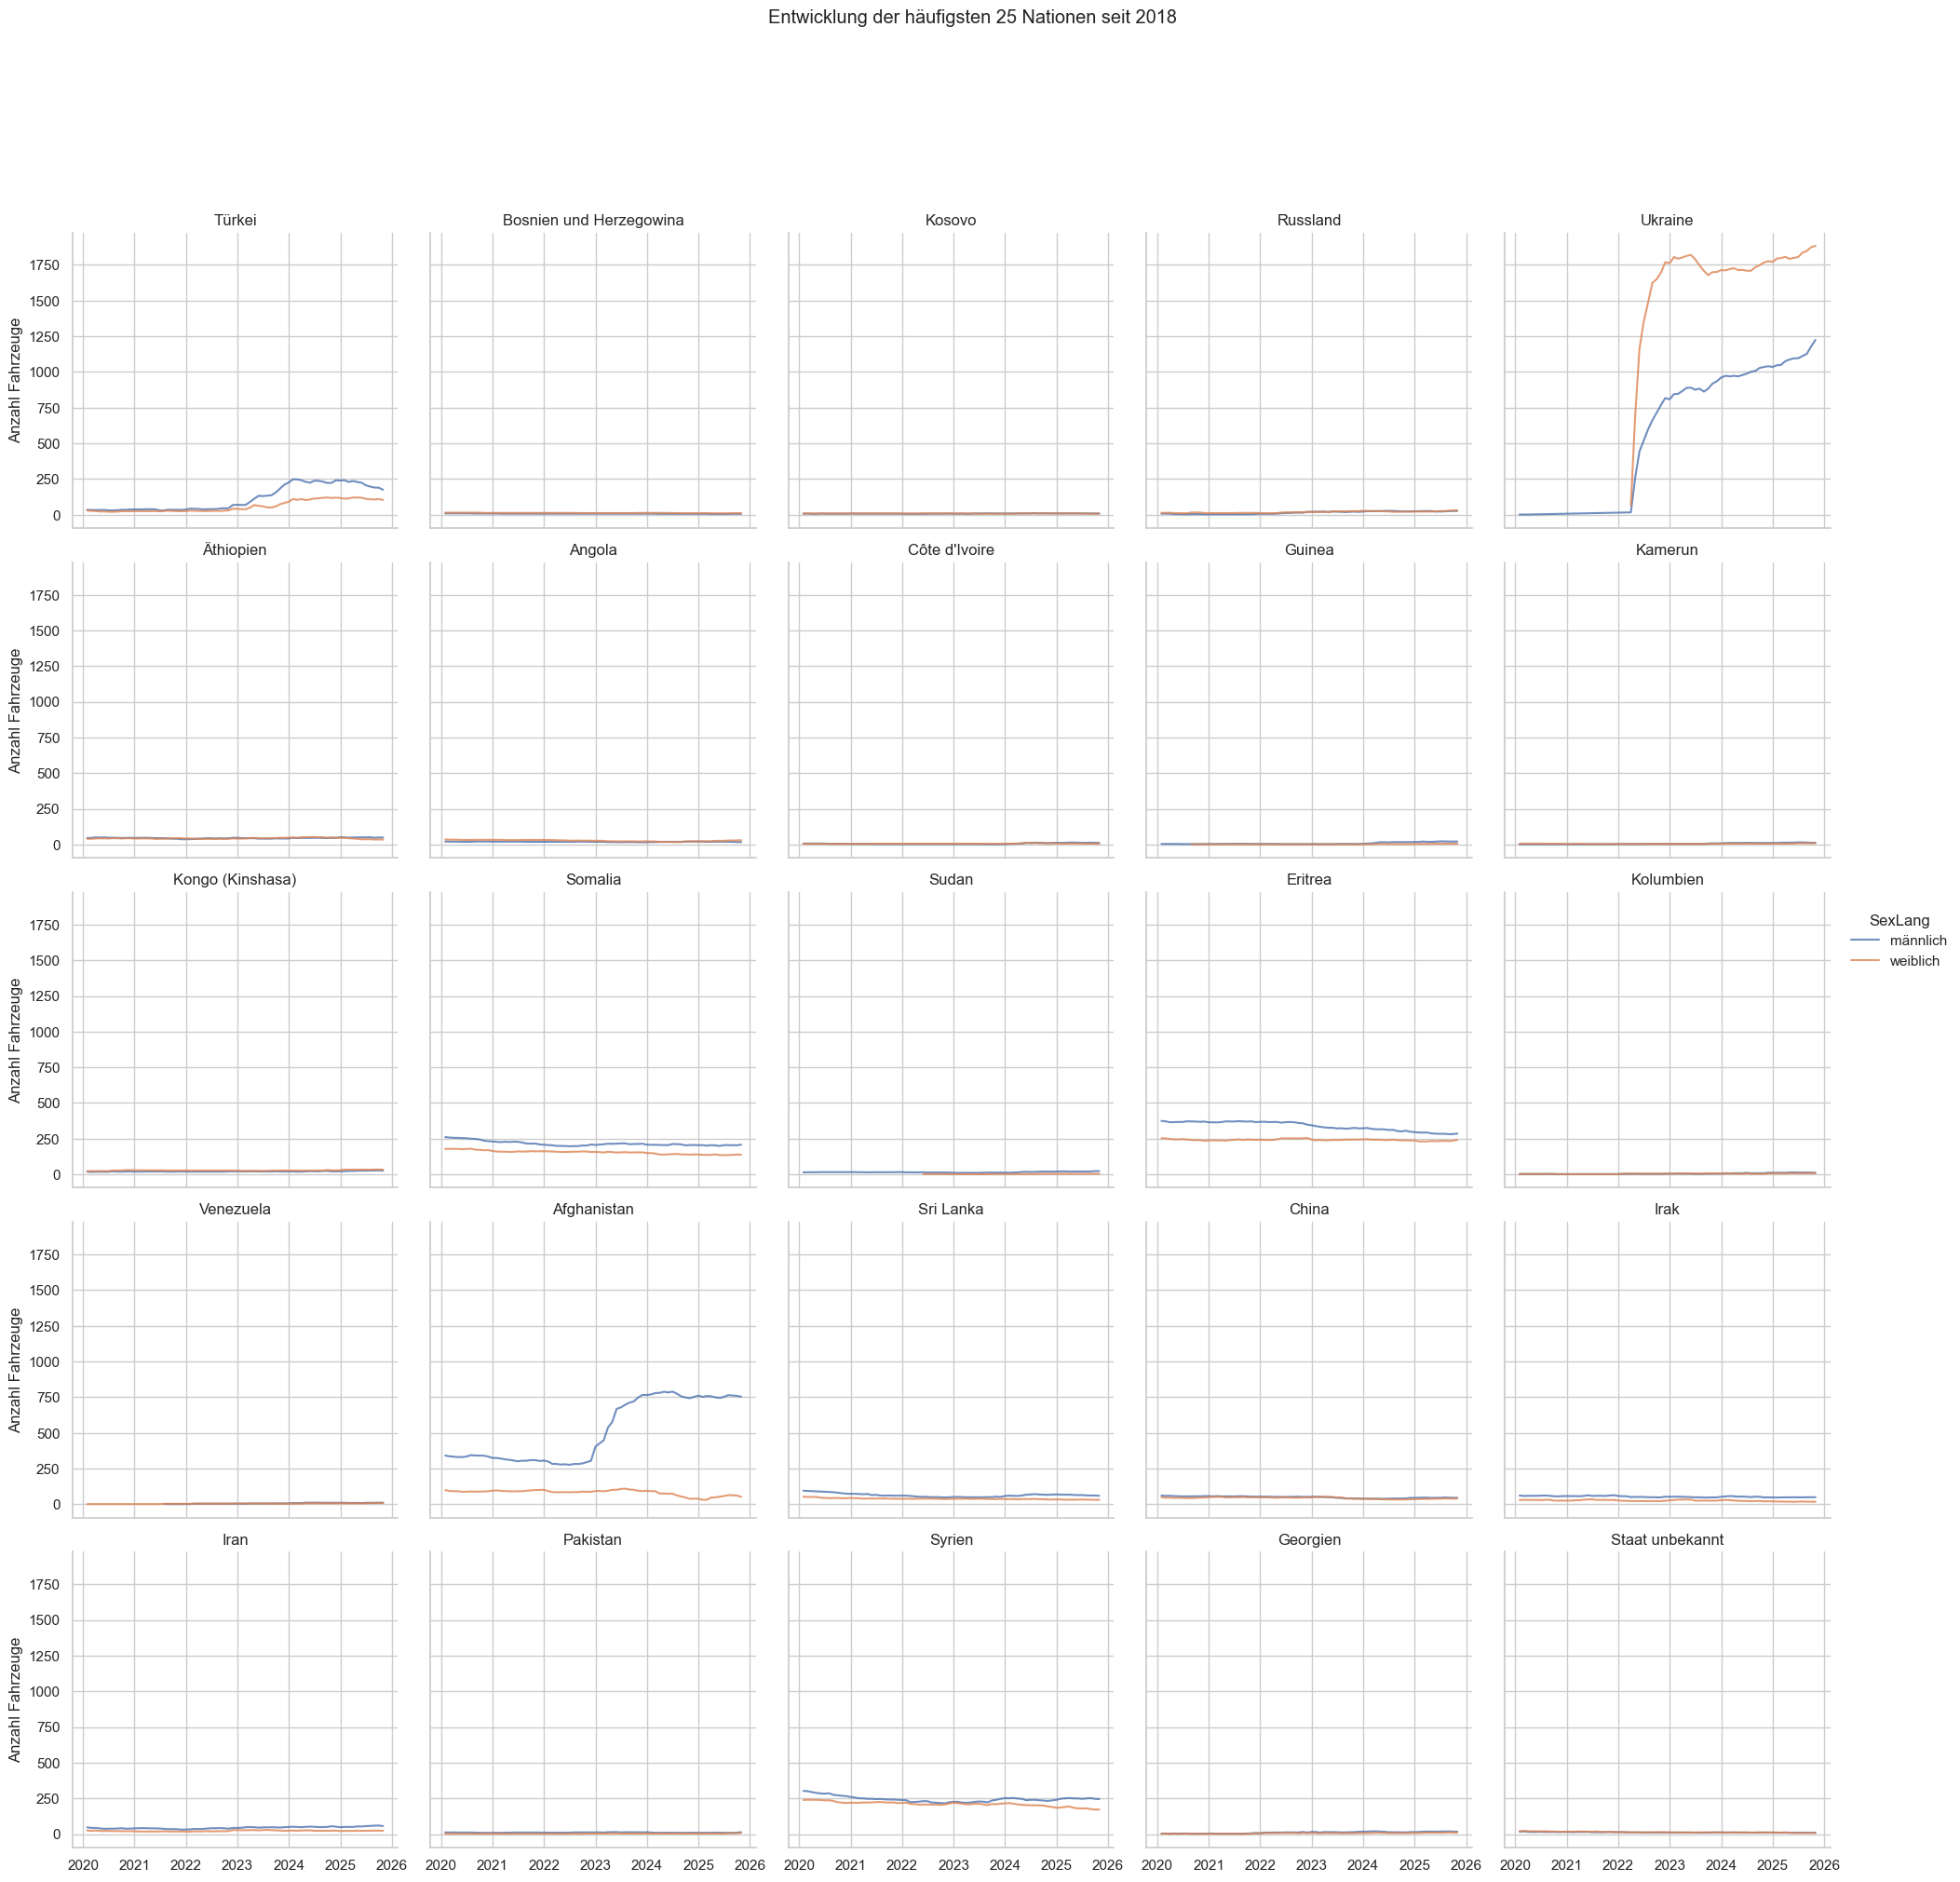

In [155]:
faced_grid = mypy_dv.plot_sns_facetgrid(
    data = myFG1.reset_index().sort_values('NationHistSort', ascending=True)
    ,col = "NationHistLang"
    ,hue = "SexLang"
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDat"
    ,y = "sum_Anz"
    ,ylabel= "Anzahl Fahrzeuge"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Entwicklung der häufigsten 25 Nationen seit "+data_min_date
)
faced_grid

In [156]:
data2betested.reset_index().columns

Index(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'AufenthaltsstatusSort',
       'AufenthaltsstatusLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd',
       'NationHistLang', 'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd',
       'KontinentLang', 'Anzahl', 'Jahr_str'],
      dtype='object')

In [157]:
myFG3 = data2betested.loc["2021":data_max_date].reset_index()\
    .query('NationHistLang in @list_top_5_latest_year')\
    .groupby(['StichtagDat','Jahr_str', 'Jahr','MonatSort','NationHistLang']) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('Jahr_str', ascending=True) 

myFG3.reset_index().head(3)

,StichtagDat,Jahr_str,Jahr,MonatSort,NationHistLang,sum_Anz
0,2021-01-31,2021,2021,1,Afghanistan,421
1,2021-07-31,2021,2021,7,Somalia,383
2,2021-07-31,2021,2021,7,Syrien,471


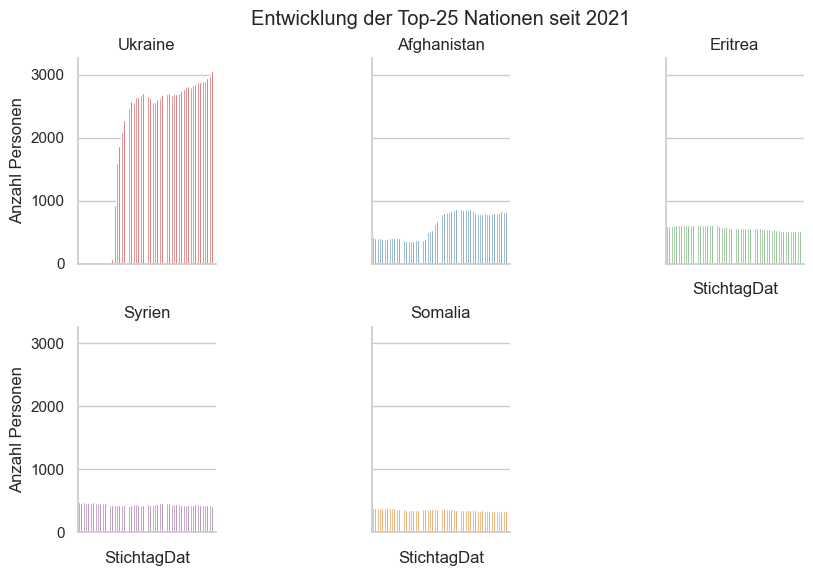

In [158]:
# Beispiel-Daten
data = myFG3.reset_index().sort_values(['StichtagDat','sum_Anz'], ascending=[False, False])

# Reihenfolge der Jahre festlegen (sortiert)
jahr_order = sorted(data['StichtagDat'].unique())
#print(jahr_order)

# FacetGrid erstellen
facet_grid = sns.FacetGrid(
    data=data,
    col="NationHistLang",
    hue="NationHistLang",
    col_wrap=3,
    height=3,
    palette="Set1"
)

# Barplot auf jedes Facet anwenden
facet_grid.map(
    sns.barplot,
    "StichtagDat",  # x-Achse
    "sum_Anz", # y-Achse
    order=jahr_order  
)

# Titel und Achsenbeschriftungen hinzufügen
facet_grid.set_axis_labels("StichtagDat", "Anzahl Personen")
facet_grid.set_titles("{col_name}")
facet_grid.set_xticklabels(rotation=45)
# Nach facet_grid.map()

#facet_grid.add_legend()

# Layout anpassen und anzeigen
plt.subplots_adjust(top=0.9)
facet_grid.fig.suptitle("Entwicklung der Top-25 Nationen seit 2021")

plt.show()

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [159]:
qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
qual12da = ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
div9val = ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB",]
div9ntr = ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A",]
qual6b = ["#0A8DF6", "#FBB900", "#99C32E", "#FC4C99", "#349894", "#44B14A",]

In [160]:
df_sel_top5_since2002.head(2)

,StichtagDat,Jahr,NationHistSort,NationHistCd,NationHistLang,sum_Anz,StichtagDat_str
0,2025-10-31,2025,8265,8265,Ukraine,3107,2025-10-31
1,2025-10-31,2025,8501,8501,Afghanistan,806,2025-10-31


In [161]:
df_top_25_alltime = agg_NationHist.reset_index().sort_values('sum_Anzahl', ascending=False).head(25)
df_top_5_alltime  = agg_NationHist.reset_index().sort_values('sum_Anzahl', ascending=False).head(5)
df_top_25_alltime.head(2)
#df_list_top_15_23 = top_15[['FzMarkeLang','sum_FzAnz']]
list_top_25_alltime = df_top_25_alltime['NationHistLang'].tolist()
list_top_5_alltime = df_top_5_alltime['NationHistLang'].tolist()
list_continents = data2betested['KontinentLang'].unique().tolist()

In [162]:
attr2becolored = list_top_25_alltime
# Verfügbare Farben
verfügbare_farben_zuericolors = qual12da+qual12br+qual12+div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(attr2becolored):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

# Erstelle das Farben-Dictionary
farben_dict_continents = {'(?)':'lightgrey'}
for index, x in enumerate(list_continents):
    farben_dict_continents[x] = qual6b[index % len(qual6b)]

print(farben_dict_continents)

{'(?)': 'lightgrey', 'Ukraine': '#0017BF', 'Eritrea': '#0072D7', 'Afghanistan': '#00A5D2', 'Syrien': '#5E359A', 'Somalia': '#BA0062', 'Türkei': '#DA5563', 'Sri Lanka': '#00615D', 'China': '#00770F', 'Äthiopien': '#7BA600', 'Irak': '#7B4100', 'Iran': '#DC5500', 'Angola': '#DA9C00', 'Kongo (Kinshasa)': '#5D4BFE', 'Russland': '#4AA9FF', 'Staat unbekannt': '#55FFFF', 'Bosnien und Herzegowina': '#986AD5', 'Serbien': '#FC4C99', 'Libyen': '#FF919A', 'Kosovo': '#349894', 'Sudan': '#44B14A', 'Staatenlos': '#B7E14E', 'Georgien': '#B97624', 'Pakistan': '#FF7231', 'Mongolei': '#FFD736', 'Burundi': '#3431DE'}
{'(?)': 'lightgrey', 'Europa': '#0A8DF6', 'Afrika': '#FBB900', 'Asien': '#99C32E', 'Unzuteilbar': '#FC4C99', 'Amerika': '#349894'}


In [163]:
data2betested.reset_index().columns

Index(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'AufenthaltsstatusSort',
       'AufenthaltsstatusLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd',
       'NationHistLang', 'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd',
       'KontinentLang', 'Anzahl', 'Jahr_str'],
      dtype='object')

In [164]:
myTreemapAgg = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDat', 'Jahr','AufenthaltsstatusLang','SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd','NationHistLang', 'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd','KontinentLang', ]) \
    .agg(sum_Anz=('Anzahl', 'sum')) \
    .sort_values('sum_Anz', ascending=False) 

myTreemapAgg.reset_index().head(2)

,StichtagDat,Jahr,AufenthaltsstatusLang,SexSort,SexCd,SexLang,NationHistSort,...,RegionSort,RegionCd,RegionLang,KontinentSort,KontinentCd,KontinentLang,sum_Anz
0,2025-10-31,2025,Ausweis S,2,2,weiblich,8265,...,12,12,Osteuropa,1,1,Europa,1873
1,2025-09-30,2025,Ausweis S,2,2,weiblich,8265,...,12,12,Osteuropa,1,1,Europa,1863


In [165]:
data_min_date = data2betested.index.min()
print(data_min_date)
data_max_date = data2betested.index.max()
print(data_max_date)

2018-05-31 00:00:00
2025-10-31 00:00:00


##### Anzahl Personen nach Jahr, Nationaliät und Geschlecht

In [166]:
treeMap0 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[[data_min_date,data_max_date]]
    ,levels=['Jahr','NationHistLang','SexLang']
    ,values="Anzahl"
    ,color="NationHistLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle=f"Anzahl Personen im Asylwesen nach Nationalität, Aufenthaltsstatus, Geschlecht, {data_min_date.year} vs {data_max_date.year}"
)
treeMap0

path: [<plotly.express._special_inputs.Constant object at 0x000002EC02038F90>, 'Jahr', 'NationHistLang', 'SexLang']
Typ von path: <class 'list'>


In [167]:
data2betested.reset_index().columns

Index(['StichtagDat', 'Jahr', 'MonatSort', 'MonatLang', 'AufenthaltsstatusSort',
       'AufenthaltsstatusLang', 'SexSort', 'SexCd', 'SexLang', 'NationHistSort', 'NationHistCd',
       'NationHistLang', 'RegionSort', 'RegionCd', 'RegionLang', 'KontinentSort', 'KontinentCd',
       'KontinentLang', 'Anzahl', 'Jahr_str'],
      dtype='object')

In [168]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[[data_min_date,data_max_date]]
    ,levels=['KontinentLang','NationHistLang','AufenthaltsstatusLang','SexLang',]
    ,values="Anzahl"
    ,color="NationHistLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_zc
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle=f"Anzahl Personen im Asylwesen nach Nationalität, Aufenthaltsstatus, Geschlecht, {data_max_date.strftime('%Y-%m-%d')}"
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x000002EC0AD39390>, 'KontinentLang', 'NationHistLang', 'AufenthaltsstatusLang', 'SexLang']
Typ von path: <class 'list'>


In [169]:
treeMap2 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[[data_min_date,data_max_date]]
    ,levels=['KontinentLang','SexLang','NationHistLang','AufenthaltsstatusLang',]
    ,values="Anzahl"
    ,color="KontinentLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=farben_dict_continents
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle=f"Anzahl Personen im Asylwesen nach Nationalität, Aufenthaltsstatus, Geschlecht, {data_max_date.strftime('%Y-%m-%d')}"
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x000002EC021052D0>, 'KontinentLang', 'SexLang', 'NationHistLang', 'AufenthaltsstatusLang']
Typ von path: <class 'list'>


In [170]:
sex_color = {'(?)': 'lightgrey', 'männlich': "#FFD736", 'weiblich': "#349894",}

In [171]:
treeMap3 = mypy_dv.plot_px_treemap(
    data=data2betested.loc[[data_min_date,data_max_date]]
    ,levels=['KontinentLang','SexLang','NationHistLang'] #, 'AufenthaltsstatusLang'
    ,values="Anzahl"
    ,color="SexLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map=sex_color
    ,height=600
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle=f"Anzahl Personen im Asylwesen nach Kontinent, Nationalität und Geschlecht, {data_max_date.strftime('%Y-%m-%d')}"
)
treeMap3

path: [<plotly.express._special_inputs.Constant object at 0x000002EC03E4A1D0>, 'KontinentLang', 'SexLang', 'NationHistLang']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://kollaboration.intranet.stzh.ch/orga/ssz-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1269&Source=https%3A%2F%2Fkollaboration%2Eintranet%2Estzh%2Ech%2Forga%2Fssz%2Dprodukte%2FLists%2FSASA%5FOutputs%2FPersonalViews%2Easpx%3FPageView%3DPersonal%26ShowWebPart%3D%7B6087A3E7%2D8AC8%2D40BA%2D8278%2DDECFACE124FF%7D%23InplviewHash6087a3e7%2D8ac8%2D40ba%2D8278%2Ddecface124ff%3D&ContentTypeId=0x0100988EAF029F1EFE4CA675F53C32A5D53D01006DBC563E6FBE9E4EB6FDC780799752E1)**

---------------------------------------------------------------------------